# Введите текст 

In [ ]:
#pipiska
import numpy as np #maths and arrays
import matplotlib.pyplot as plt #graphics
import pandas as pd #data tables
import seaborn as sns #graphics
from sklearn.model_selection import train_test_split #to divide data

In [ ]:
data = pd.read_csv('housing_data.csv') # datasset upload
print(data.head()) # print first 5 table strings 
print(data.shape) # dimensionality of the matrix
print(data.isnull().sum()) # find skips
print(data.describe()) # medium, min, max percentiles

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup   Latitude  \
0  3.484613      24.0  8.900650   3.920299      1907.0  3.645688  37.630902   
1  2.536710      51.0  6.643193   3.428366      1020.0  4.371320  40.321267   
2  3.757840      10.0  9.025676   3.410527      2491.0  3.572922  36.017830   
3  5.821249       8.0  3.038106   1.062376      1574.0  4.160802  34.322902   
4  2.417958      21.0  3.246222   1.688743       990.0  2.859072  37.922172   

    Longitude  MedHouseVal  
0 -123.743930     2.175713  
1 -123.139353     1.602996  
2 -122.510577     1.954418  
3 -122.705254     2.280773  
4 -121.535075     1.759883  
(4000, 9)
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
            MedInc     HouseAge     AveRooms    AveBedrms   Population  \
count  4000.000000  4000.000000  4000.000000  4000.000000  4000.000000   
mean      3.109748    27.28

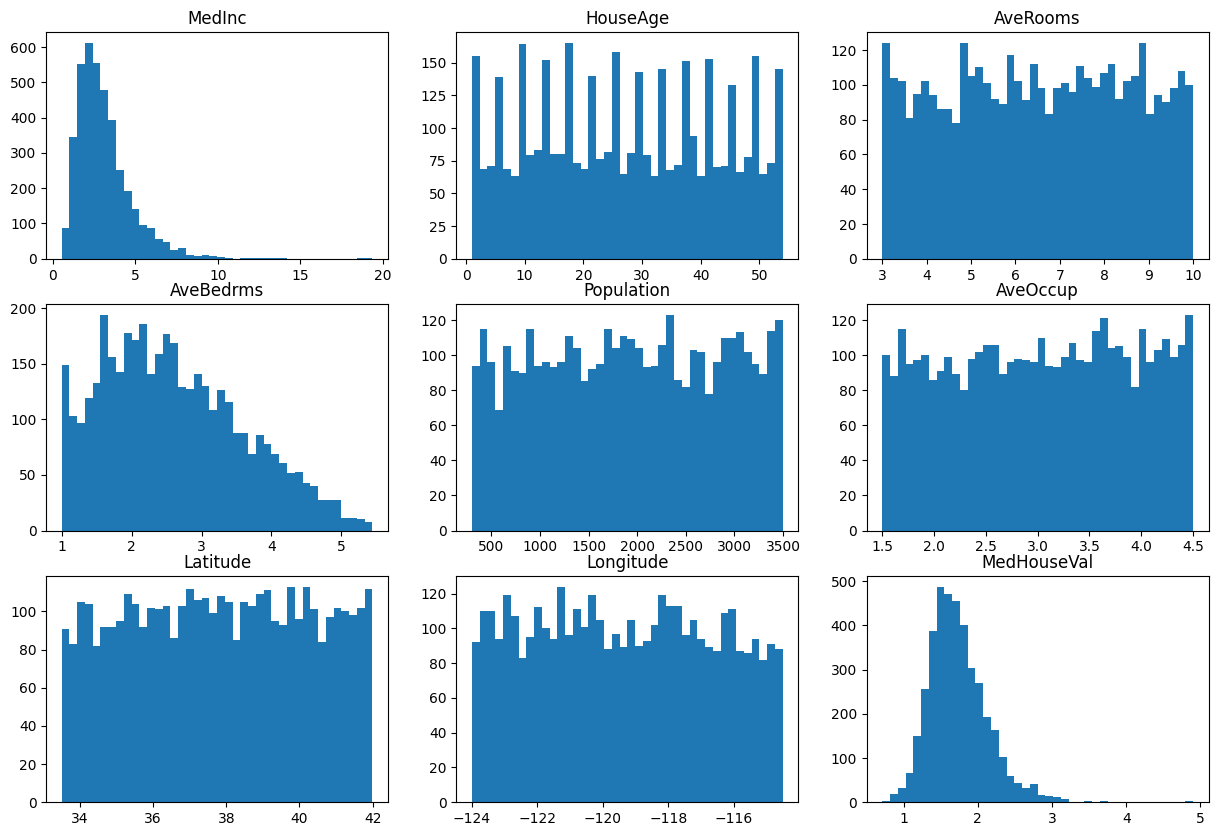

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15,10)) # create canvas 3x3
axes=axes.flatten() #transform matrix to vector
for i, col in enumerate(data.columns): #for every column
    axes[i].hist(data[col], bins=40) #create histogram
    axes[i].set_title(col)
plt.tight_layout #nezn
plt.show() #visualize 

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.029151 -0.023197  -0.020802    0.012288 -0.004332   
HouseAge    -0.029151  1.000000 -0.002072  -0.005711   -0.017725  0.010767   
AveRooms    -0.023197 -0.002072  1.000000   0.812138   -0.003684 -0.013188   
AveBedrms   -0.020802 -0.005711  0.812138   1.000000    0.005105 -0.012911   
Population   0.012288 -0.017725 -0.003684   0.005105    1.000000  0.000294   
AveOccup    -0.004332  0.010767 -0.013188  -0.012911    0.000294  1.000000   
Latitude     0.007753  0.015160 -0.009796  -0.019638    0.008127 -0.005768   
Longitude    0.007920 -0.014868  0.024161  -0.002240   -0.025409 -0.015664   
MedHouseVal  0.886454  0.108177  0.081436   0.068482    0.008140 -0.108938   

             Latitude  Longitude  MedHouseVal  
MedInc       0.007753   0.007920     0.886454  
HouseAge     0.015160  -0.014868     0.108177  
AveRooms    -0.009796   0.024161     0.081436  
AveBedrms   -0.019638  -0.0

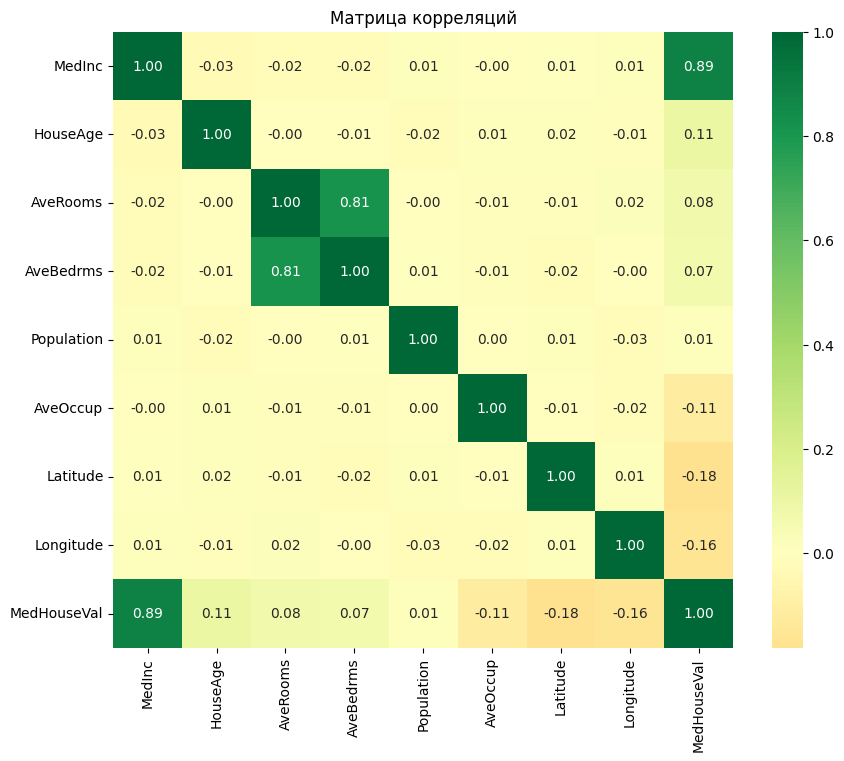

In [ ]:
print(data.corr()) # raw data correlation
plt.figure(figsize=(10, 8)) #create fig

#create heatmap for data corr (1 - direct, 0 - no, -1 - reverse)
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0) 
plt.title('Матрица корреляций')
plt.show()

In [ ]:
#create new features
data['LogMedInc'] = np.log1p(data['MedInc'])
data['BedroomRatio'] = np.log1p(data['AveBedrms'])
data['RoomsPerPerson'] = np.log1p(data['AveRooms'])
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,LogMedInc,BedroomRatio,RoomsPerPerson
0,3.484613,24.0,8.900650,3.920299,1907.0,3.645688,37.630902,-123.743930,2.175713,1.500652,1.593369,2.292600
1,2.536710,51.0,6.643193,3.428366,1020.0,4.371320,40.321267,-123.139353,1.602996,1.263197,1.488031,2.033815
2,3.757840,10.0,9.025676,3.410527,2491.0,3.572922,36.017830,-122.510577,1.954418,1.559794,1.483994,2.305149
3,5.821249,8.0,3.038106,1.062376,1574.0,4.160802,34.322902,-122.705254,2.280773,1.920043,0.723859,1.395776
4,2.417958,21.0,3.246222,1.688743,990.0,2.859072,37.922172,-121.535075,1.759883,1.229043,0.989074,1.446030


hai!! thanks for reading this far <3

In [ ]:
#list of columns we actually need
cols = ['MedInc', 'HouseAge', 'Population', 'AveOccup', 'LogMedInc', 'BedroomRatio', 'RoomsPerPerson']
X = data[cols] # table of features based by which the model will predict
y = data['MedHouseVal'] 
print(X.shape) #size of table
print(y.shape) # column of correct answers 

(4000, 7)
(4000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% of data will be used for test
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(3200, 7)
(800, 7)
